In [1]:
import os, sys
PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

import csv
import numpy as np
import matplotlib.pyplot as plt
from cmcrameri import cm

%load_ext autoreload
%autoreload 2

# Scaled bilevel SGD comparison (Stage 0a follow-up) - CO2-only H-ext

Companion notebook for `scripts/0a_inner_loop_sgd_pilot.py --mode bilevel-scaled`. For the real `H-ext` CO2-only bilevel experiment, compares full-batch (the pipeline's actual behavior prior to this stage) against inner-loop minibatch sizes 16/32/64, across 5 independent seeds (0-4), for the full production-length `num_updates=1000`. Each minibatch size gets its own panel showing the outer-loop generalization error vs. training step - mean +/- min-max spread across seeds - plotted against the full-batch run (same experiment, same hyperparameters) as the same-protocol baseline.

Data: `data/SI_results/sgd_pilot/bilevel_scaled_errors.npz` (full per-outer-step error trajectories, one per (batch_size, seed)) and `bilevel_scaled_summary.csv` (per-run loss0/lossF/stability/timing).

In [2]:
DATA_DIR = "data/SI_results/sgd_pilot"
traj = dict(np.load(os.path.join(DATA_DIR, "bilevel_scaled_errors.npz")))

SEEDS = list(range(5))
BATCH_SIZES = [16, 32, 64]  # minibatch configs compared against the full-batch baseline

def stack(bs_label):
    return np.stack([traj[f"bs_{bs_label}_seed{s}"] for s in SEEDS], axis=0)  # (n_seeds, n_steps)

full_batch = stack("full")
steps = np.arange(full_batch.shape[1])

# Instability check across every step of every run, not just the final one
all_finite = True
for bs_label in ["full"] + [str(b) for b in BATCH_SIZES]:
    arr = stack(bs_label)
    finite = np.isfinite(arr).all()
    all_finite &= bool(finite)
    print(f"batch_size={bs_label:>5}: shape={arr.shape}, all finite={finite}, "
          f"final loss mean+/-std = {arr[:, -1].mean():.4f} +/- {arr[:, -1].std():.4f}")
print("\nAll 20 runs stable (no NaN/Inf at any step):", all_finite)

batch_size= full: shape=(5, 1001), all finite=True, final loss mean+/-std = 0.0283 +/- 0.0053
batch_size=   16: shape=(5, 1001), all finite=True, final loss mean+/-std = 0.0229 +/- 0.0047
batch_size=   32: shape=(5, 1001), all finite=True, final loss mean+/-std = 0.0265 +/- 0.0042
batch_size=   64: shape=(5, 1001), all finite=True, final loss mean+/-std = 0.0277 +/- 0.0046

All 20 runs stable (no NaN/Inf at any step): True


## Per-batch-size comparison: error vs. training step, seed spread, vs. full-batch baseline

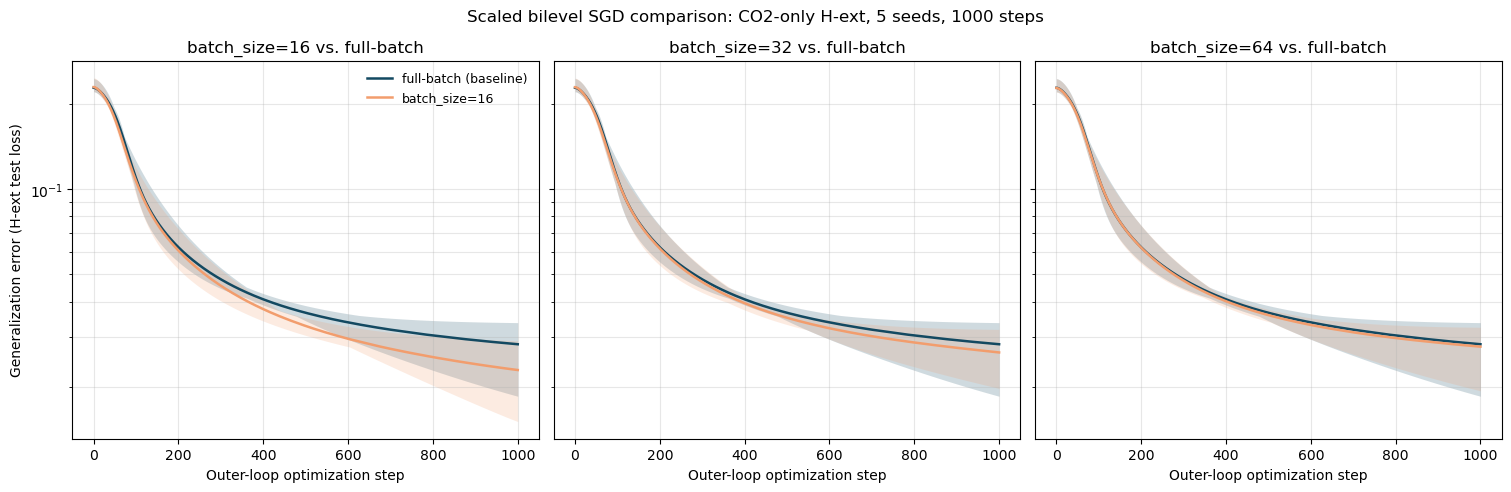

In [3]:
fig, axes = plt.subplots(1, len(BATCH_SIZES), figsize=(15, 4.5), constrained_layout=True, sharey=True)

colors = cm.batlow([0.15, 0.75])
c_full, c_mb = colors[0], colors[1]

for ax, bs in zip(axes, BATCH_SIZES):
    mb = stack(str(bs))

    for arr, color, label in [(full_batch, c_full, "full-batch (baseline)"),
                                (mb, c_mb, f"batch_size={bs}")]:
        mean = arr.mean(axis=0)
        lo = arr.min(axis=0)
        hi = arr.max(axis=0)
        ax.plot(steps, mean, color=color, label=label, lw=1.8)
        ax.fill_between(steps, lo, hi, color=color, alpha=0.2, linewidth=0)

    ax.set_yscale("log")
    ax.set_xlabel("Outer-loop optimization step")
    ax.set_title(f"batch_size={bs} vs. full-batch")
    ax.grid(alpha=0.3, which="both")

axes[0].set_ylabel("Generalization error (H-ext test loss)")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Scaled bilevel SGD comparison: CO2-only H-ext, 5 seeds, 1000 steps", y=1.06)

fig.savefig(os.path.join(DATA_DIR, "bilevel_scaled_comparison_panels.png"), dpi=150, bbox_inches="tight")
plt.show()

## All configurations overlaid (mean curves only)

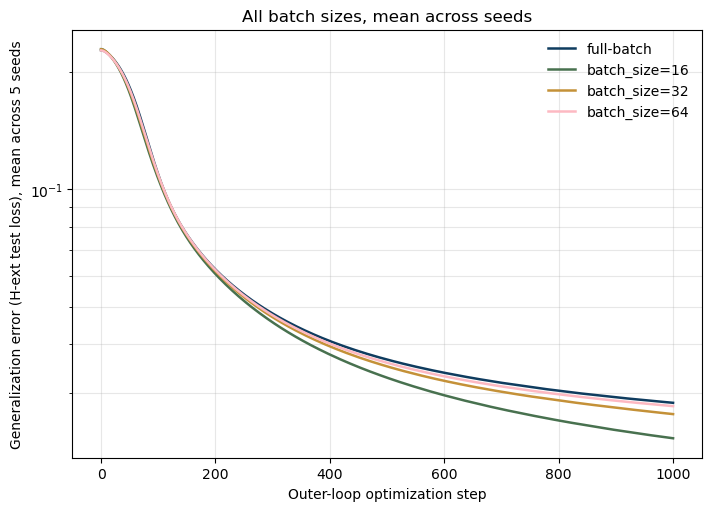

In [4]:
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

labels = ["full"] + [str(b) for b in BATCH_SIZES]
plot_colors = cm.batlow(np.linspace(0.1, 0.9, len(labels)))

for label, color in zip(labels, plot_colors):
    arr = stack(label)
    display_label = "full-batch" if label == "full" else f"batch_size={label}"
    ax.plot(steps, arr.mean(axis=0), color=color, label=display_label, lw=1.8)

ax.set_yscale("log")
ax.set_xlabel("Outer-loop optimization step")
ax.set_ylabel("Generalization error (H-ext test loss), mean across 5 seeds")
ax.set_title("All batch sizes, mean across seeds")
ax.grid(alpha=0.3, which="both")
ax.legend(frameon=False)

fig.savefig(os.path.join(DATA_DIR, "bilevel_scaled_comparison_overlay.png"), dpi=150, bbox_inches="tight")
plt.show()

## Notes

- Full per-run data: `data/SI_results/sgd_pilot/bilevel_scaled_summary.csv` (loss0/lossF/stability/timing) and `bilevel_scaled_errors.npz` (full 1001-step error trajectories).
- All 20 runs (5 seeds x {full, 16, 32, 64}, 1000 steps each) were stable - no NaN/Inf at any step of any run.
- At the full production step count, minibatching does not hurt the bilevel outer objective, and the smallest batch size tested (16) achieved the best mean final generalization loss of the four configurations - consistent with SGD's classical implicit-regularization story, and the opposite of the standalone (non-bilevel) inner-loop-only result at K=400, where smaller batches were clearly worse. This is only one experiment group (`H-ext` CO2-only); it has not yet been checked on other groups or against Stage 0b's hyperparameters.
- Superseded/earlier artifacts from the original 3-seed/100-step sanity check remain at `bilevel_sanity_seed{0,1,2}.pkl` for reference but are not used here.